In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from itertools import combinations
import cmocean as cmc
import cmcrameri as cmcr
from scipy.stats import spearmanr

#plt.style.use('../plotstyling.mplstyle')

In [10]:
db_filename = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
ds = xr.open_dataset(db_filename)

In [11]:
NEDeltaT = np.array([0.21, 0.36, 0.50, 0.56, 0.79, 0.84, 1.0, 0.91, 1.05, 1.53, 1.6])

Fwp = ds.Fwp.values
Fwc = ds.Fwc.values
Zm = ds.Fwp_Zm.values / 1000
Latitude = ds.Latitude.values
Longitude = ds.Longitude.values
Surf_z = ds.Surf_Z.values
altitude = ds.vertical_level.values / 1000
altitude_in_m = ds.vertical_level.values

channels = ["AWS21", "AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]
channels_diffs = ["21-31", "31-32", "32-33", "33-34", "34-35", "35-36", "36-44", "44-43", "43-42", "42-41"]

Ta_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array[:,i] = ds[f"Ta_Allsky_{ch}"].values

CS_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array[:,i] = ds[f"Ta_Clearsky_{ch}"].values - ds[f"Ta_Allsky_{ch}"].values

CS_array_noisy = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array_noisy[:,i] = CS_array[:,i] + np.random.normal(0, NEDeltaT[i], CS_array[:,i].shape[0])


dtB_32_36 = ds[f"Ta_Allsky_AWS32"].values - ds[f"Ta_Allsky_AWS36"].values

dtB_35_33 = ds[f"Ta_Allsky_AWS35"].values - ds[f"Ta_Allsky_AWS33"].values
dtB_35_34 = ds[f"Ta_Allsky_AWS35"].values - ds[f"Ta_Allsky_AWS34"].values
dtB_34_33 = ds[f"Ta_Allsky_AWS34"].values - ds[f"Ta_Allsky_AWS33"].values
dtB_36_44 = ds[f"Ta_Allsky_AWS36"].values - ds[f"Ta_Allsky_AWS44"].values

Ta_3236 = np.stack([
    ds["Ta_Allsky_AWS32"].values,
    ds["Ta_Allsky_AWS33"].values,
    ds["Ta_Allsky_AWS34"].values,
    ds["Ta_Allsky_AWS35"].values,
    ds["Ta_Allsky_AWS36"].values,
], axis=-1)

In [12]:
case = "fave"

if case == "amazon":
    filter_info = {
        "Fwp": 1,
        "surface_altitude": 500,
        "Zm": 6
    }
    
    filter_idxs = np.where(
        (Fwp > filter_info["Fwp"])
        & (Surf_z < filter_info["surface_altitude"])
        & (Zm > filter_info["Zm"])
        & (Latitude < 5)
        & (Latitude > -15)
        & (Longitude < -40)
        & (Longitude > -80)
        #& (np.abs(dtB_32_36) < 2)
    )[0]

elif case == "cloudy_mid_latitudes":
    filter_info = {
        "Fwp": 1e-1,
    }
    
    filter_idxs = np.where(
        (Fwp > filter_info["Fwp"])
        & (np.abs(Latitude) < 60)
        & (np.abs(Latitude) > 30)
    )[0]
    title = r"Latitude in $\pm$[30, 60], FWP $>$ 100 g m$^{-2}$"

elif case == "low_fwp":
    filter_info = {
        "Fwp": 1e-1,
    }
    
    filter_idxs = np.where(
        (Fwp < filter_info["Fwp"])
        & (Fwp > 1e-2)
        & (Latitude < 60)
        & (Latitude > -60)
    )[0]
    title = r"FWP in [10, 100] g m$^{-2}$"

elif case == "mid_fwp_lower":
    
    filter_idxs = np.where(
        (Fwp < 5e-1)
        & (Fwp > 5e-3)
        & (Latitude < 60)
        & (Latitude > -60)
    )[0]
    title = r"FWP in [5, 500] g m$^{-2}$"

elif case == "really_low_fwp":
    
    filter_idxs = np.where(
        (Fwp < 1e-2)
        & (Fwp > 1e-3)
        & (Latitude < 60)
        & (Latitude > -60)
    )[0]
    title = r"FWP in [1, 10] g m$^{-2}$"


elif case == "fave":
    
    filter_idxs = np.where(
        (Fwp > 5e-3)
        & (Fwp < 2e-1)
        & (np.abs(Latitude) < 60)
        #& (np.abs(Latitude) > 30)
    )[0]
    title = r"FWP in [5, 200] g m$^{-2}$, lat in $\pm$[-60,60]"




print("Number of cases: ", len(filter_idxs))

Number of cases:  1008361


In [13]:
layer_height = 8
iters = range(2, len(altitude_in_m) + 1, layer_height)
n_iters = len(range(2, len(altitude_in_m) + 1, layer_height))
correlations = np.zeros((n_iters-1, 11))

for i, n in enumerate(iters):
    if i == 0:
        continue
    Fwc_layer = Fwc[filter_idxs, -n:]
    z = altitude_in_m[-n:]
    Fwp_layer = np.trapezoid(Fwc_layer, z)

    valid = Fwp_layer > 0

    #log_Fwp = np.log10(Fwp_layer[valid])
    for j in range(11):
        #r = np.corrcoef(log_Fwp, CS_array_noisy[filter_idxs][valid, j])[0, 1]
        r = np.corrcoef(Fwp_layer[valid], CS_array_noisy[filter_idxs][valid, j])[0, 1]
        correlations[i-1, j] = r
    
    #for j in range(11):
    #    r, _ = spearmanr(Fwp_layer[valid], CS_array_noisy[filter_idxs][valid, j])
    #    correlations[i, j] = r

y_labels = [
    f"{altitude_in_m[-n]/1000:.2f}–{altitude_in_m[-1]/1000:.1f}"
    for n in range(2, len(altitude_in_m) + 1, layer_height)
]


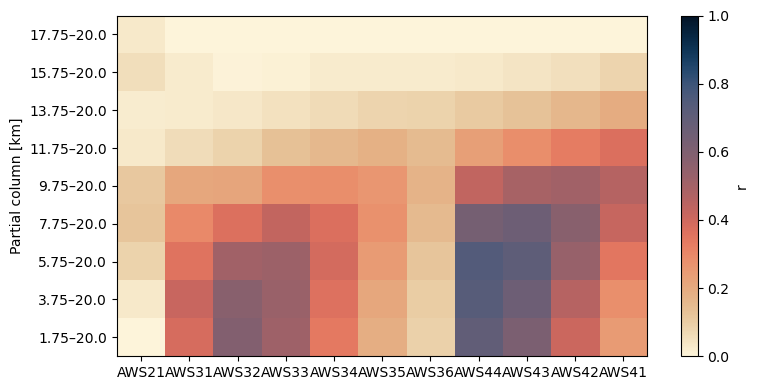

In [14]:

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(correlations, aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)

plt.colorbar(im, ax=ax, label="r")

ax.set_xticks(range(11))
ax.set_xticklabels([f"{ch}" for ch in channels])
ax.set_yticks(range(len(y_labels)-1))
ax.set_yticklabels(y_labels[1:])

ax.set_ylabel("Partial column [km]")
#ax.set_title(f"Correlation between Fwp and cloud signal\n{title}\nPartial columns")
#ax.set_title(f"Correlation between Fwp and cloud signal\nALL")

plt.tight_layout()
plt.savefig(
    f"../figures/correlations/CS_FWP_correlation_{case}_partial_columns_no_log_no_zeros.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

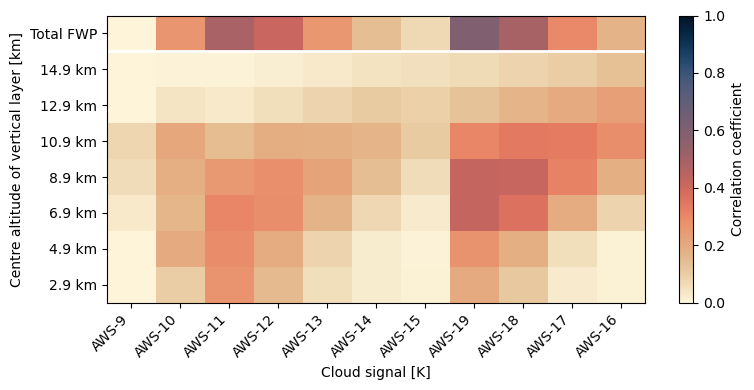

In [20]:
# ── compute correlations ──
layer_height = 8
layer_edges = list(range(0, len(altitude_in_m) - 1, layer_height))[1:-2]

correlations_no_overlap = np.zeros((len(layer_edges), 11))
for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)
    valid = Fwp_layer > 0
    for j in range(11):
        #r = np.corrcoef(Fwp_layer[valid], CS_array_noisy[filter_idxs][valid, j])[0, 1]
        r, _ = spearmanr(Fwp_layer[valid], CS_array_noisy[filter_idxs][valid, j])
        correlations_no_overlap[i, j] = r

# ── correlation with total FWP ──
valid_total = Fwp[filter_idxs] > 0
corr_total = np.array([
    #np.corrcoef(Fwp[filter_idxs][valid_total], CS_array_noisy[filter_idxs][valid_total, j])[0, 1]
    #np.corrcoef(Fwp[filter_idxs][valid_total], CS_array_noisy[filter_idxs][valid_total, j])[0, 1]
    spearmanr(Fwp[filter_idxs][valid_total], CS_array_noisy[filter_idxs][valid_total, j])[0]
    for j in range(11)
])
correlations_with_total = np.vstack([correlations_no_overlap, corr_total])

y_labels = [
    f"{(altitude_in_m[start] + altitude_in_m[start + layer_height - 1]) / 2 / 1000:.1f} km"
    for start in layer_edges
]
y_labels_with_total = y_labels + ["Total FWP"]

# ── plot ──
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(correlations_with_total[::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Correlation coefficient")
ax.set_xticks(range(11))
ax.set_xticklabels([f"AWS-{i+9}" for i, ch in enumerate(channels[:-4])] + ["AWS-19", "AWS-18", "AWS-17", "AWS-16"], rotation=45, ha="right")
ax.set_yticks(range(len(y_labels_with_total)))
ax.set_yticklabels(y_labels_with_total[::-1])
ax.set_ylabel("Centre altitude of vertical layer [km]")
ax.set_xlabel("Cloud signal [K]")
#ax.set_title(f"Correlation between layer FWP and CS\n{title}\nSpecific layers")
ax.axhline(y=0.5, color="white", linewidth=2)
plt.tight_layout()
plt.savefig(f"../figures/correlations/CS_FWP_correlation_5_200_spearman.png",
            dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig(f"../figures/correlations/CS_FWP_correlation_5_200_spearman.pdf",
            dpi=200, bbox_inches="tight", facecolor="white")

In [8]:
for start in layer_edges:
    print(f"{altitude_in_m[start]/1e3:.2f} – {altitude_in_m[start + layer_height - 1]/1e3:.2f} km")

2.00 – 3.75 km
4.00 – 5.75 km
6.00 – 7.75 km
8.00 – 9.75 km
10.00 – 11.75 km
12.00 – 13.75 km
14.00 – 15.75 km


In [28]:
for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)
    
    valid = Fwp_layer > 0
    r_all,   _ = spearmanr(Fwp_layer,        CS_array_noisy[filter_idxs, 1])
    r_valid, _ = spearmanr(Fwp_layer[valid],  CS_array_noisy[filter_idxs, 1][valid])
    print(f"Layer {i} ({altitude_in_m[start]/1e3:.1f} km): r_all={r_all:.3f}  r_valid={r_valid:.3f}  (n={valid.sum()})")

Layer 0 (0.0 km): r_all=-0.501  r_valid=0.007  (n=317162)
Layer 1 (2.0 km): r_all=-0.302  r_valid=0.101  (n=441705)
Layer 2 (4.0 km): r_all=0.185  r_valid=0.199  (n=564793)
Layer 3 (6.0 km): r_all=0.246  r_valid=0.163  (n=611863)
Layer 4 (8.0 km): r_all=0.316  r_valid=0.187  (n=564973)
Layer 5 (10.0 km): r_all=0.415  r_valid=0.209  (n=408093)
Layer 6 (12.0 km): r_all=0.374  r_valid=0.041  (n=214369)
Layer 7 (14.0 km): r_all=0.206  r_valid=0.007  (n=55150)
Layer 8 (16.0 km): r_all=0.038  r_valid=-0.007  (n=2111)
Layer 9 (18.0 km): r_all=0.005  r_valid=-0.068  (n=394)


In [29]:
for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z         = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)
    r, _      = spearmanr(Fwp_layer, CS_array_noisy[filter_idxs, 1])
    print(f"Layer {i:2d}  ({altitude_in_m[start]/1e3:.1f} km):  r = {r:.3f}")

Layer  0  (0.0 km):  r = -0.501
Layer  1  (2.0 km):  r = -0.302
Layer  2  (4.0 km):  r = 0.185
Layer  3  (6.0 km):  r = 0.246
Layer  4  (8.0 km):  r = 0.316
Layer  5  (10.0 km):  r = 0.415
Layer  6  (12.0 km):  r = 0.374
Layer  7  (14.0 km):  r = 0.206
Layer  8  (16.0 km):  r = 0.038
Layer  9  (18.0 km):  r = 0.005


/tmp/ipykernel_16789/9703895.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


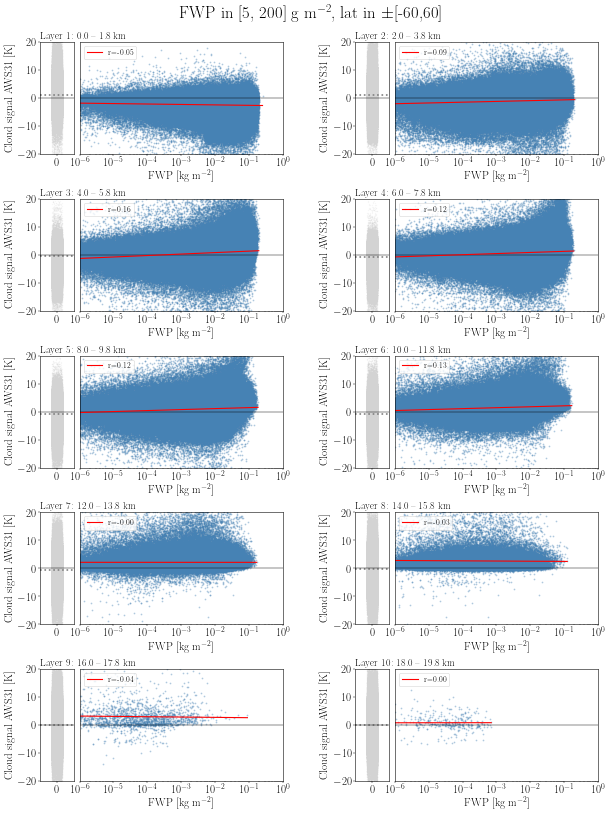

In [30]:
fig = plt.figure(figsize=(18, 24))
outer_gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.3)

y = CS_array_noisy[filter_idxs, 1]

for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z         = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)

    z_bot = altitude_in_m[start]
    z_top = altitude_in_m[start + layer_height - 1]

    valid   = Fwp_layer > 0
    zero    = ~valid
    log_x   = np.log10(Fwp_layer[valid])
    y_valid = y[valid]
    y_zero  = y[zero]

    row, col = divmod(i, 2)

    # split each cell into a narrow zero-strip + wide log scatter
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[row, col],
        width_ratios=[1, 6], wspace=0.05)

    ax_zero = fig.add_subplot(inner_gs[0])
    ax_main = fig.add_subplot(inner_gs[1])

    # --- zero strip: jitter x so points don't stack ---
    jitter = np.random.uniform(-0.3, 0.3, size=y_zero.shape)
    ax_zero.scatter(jitter, y_zero, alpha=0.1, s=3, color="lightgrey")
    ax_zero.axhline(np.mean(y_zero), c="grey", ls=":")
    ax_zero.set_xlim(-1, 1)
    ax_zero.set_ylim(-20, 20)
    ax_zero.set_xticks([0])
    ax_zero.set_xticklabels(["0"])
    ax_zero.axhline(0, c="k", lw=0.8)
    ax_zero.set_ylabel("Cloud signal AWS31 [K]")

    # --- main scatter ---
    ax_main.scatter(Fwp_layer[valid], y_valid, alpha=0.3, s=5, color="steelblue")
    ax_main.set_xscale("log")
    ax_main.set_xlim([1e-6, 1e0])
    ax_main.set_ylim(-20, 20)
    ax_main.axhline(0, c="k", lw=0.8)
    ax_main.set_yticks([])
    ax_main.set_xlabel(r"FWP [kg m$^{-2}$]")

    m, b = np.polyfit(log_x, y_valid, 1)
    x_line = np.logspace(log_x.min(), log_x.max(), 200)
    r = np.corrcoef(log_x, y_valid)[0, 1]
    ax_main.plot(x_line, m * np.log10(x_line) + b, color="red", lw=2,
                 label=f"r={r:.2f}")
    ax_main.legend(fontsize=14, loc="upper left")

    ax_title = f"Layer {i+1}:  {z_bot/1e3:.1f} – {z_top/1e3:.1f} km"
    ax_zero.set_title(ax_title, fontsize=18, loc="left")

    fig.suptitle(title, y=0.92, fontsize=30)

fig.tight_layout()
plt.savefig(f"../figures/correlations/CS31_FWP_scatter_{case}.png",
            dpi=200, bbox_inches="tight", facecolor="white")

/tmp/ipykernel_16789/3562792761.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


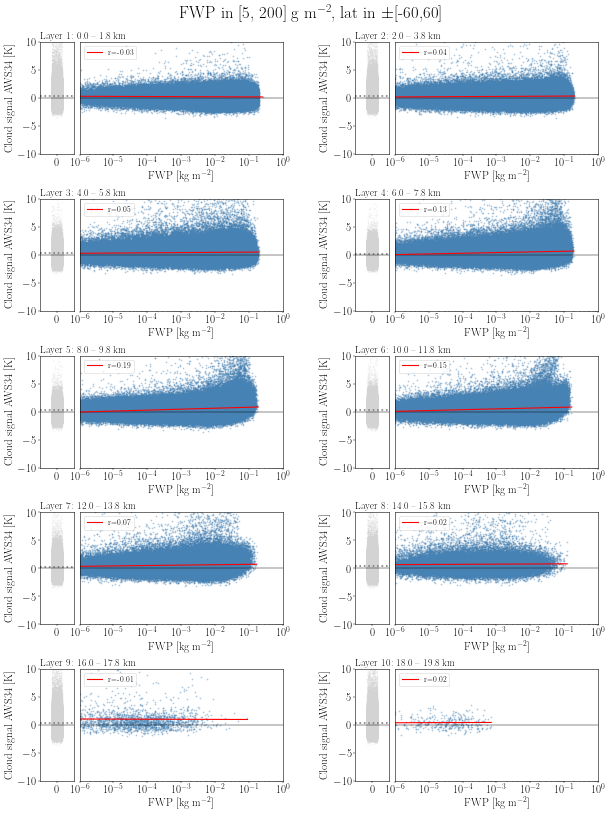

In [31]:
fig = plt.figure(figsize=(18, 24))
outer_gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.3)

y = CS_array_noisy[filter_idxs, 4]

for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z         = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)

    z_bot = altitude_in_m[start]
    z_top = altitude_in_m[start + layer_height - 1]

    valid   = Fwp_layer > 0
    zero    = ~valid
    log_x   = np.log10(Fwp_layer[valid])
    y_valid = y[valid]
    y_zero  = y[zero]

    row, col = divmod(i, 2)

    # split each cell into a narrow zero-strip + wide log scatter
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[row, col],
        width_ratios=[1, 6], wspace=0.05)

    ax_zero = fig.add_subplot(inner_gs[0])
    ax_main = fig.add_subplot(inner_gs[1])

    # --- zero strip: jitter x so points don't stack ---
    jitter = np.random.uniform(-0.3, 0.3, size=y_zero.shape)
    ax_zero.scatter(jitter, y_zero, alpha=0.1, s=3, color="lightgrey")
    ax_zero.axhline(np.mean(y_zero), c="grey", ls=":")
    ax_zero.set_xlim(-1, 1)
    ax_zero.set_ylim(-10, 10)
    ax_zero.set_xticks([0])
    ax_zero.set_xticklabels(["0"])
    ax_zero.axhline(0, c="k", lw=0.8)
    ax_zero.set_ylabel("Cloud signal AWS34 [K]")

    # --- main scatter ---
    ax_main.scatter(Fwp_layer[valid], y_valid, alpha=0.3, s=5, color="steelblue")
    ax_main.set_xscale("log")
    ax_main.set_xlim([1e-6, 1e0])
    ax_main.set_ylim(-10, 10)
    ax_main.axhline(0, c="k", lw=0.8)
    ax_main.set_yticks([])
    ax_main.set_xlabel(r"FWP [kg m$^{-2}$]")

    m, b = np.polyfit(log_x, y_valid, 1)
    x_line = np.logspace(log_x.min(), log_x.max(), 200)
    r = np.corrcoef(log_x, y_valid)[0, 1]
    ax_main.plot(x_line, m * np.log10(x_line) + b, color="red", lw=2,
                 label=f"r={r:.2f}")
    ax_main.legend(fontsize=14, loc="upper left")

    ax_title = f"Layer {i+1}:  {z_bot/1e3:.1f} – {z_top/1e3:.1f} km"
    ax_zero.set_title(ax_title, fontsize=18, loc="left")

fig.suptitle(title, y=0.92, fontsize=30)

fig.tight_layout()

plt.savefig(f"../figures/correlations/CS34_FWP_scatter_{case}.png",
            dpi=200, bbox_inches="tight", facecolor="white")